# Shabaka Pulse — Grid Frequency Digital Twin

This notebook simulates a discrete-time digital twin of the Egyptian national grid's frequency response. By modeling the grid's inertia and capacity via the standard swing equation, we simulate how a massive, sudden loss of generation (e.g., a major cloud cover event dropping 1,800 MW of solar output) impacts grid frequency. It also models Shabaka Pulse's rapid Tier-1 load shedding acting as an automated Under-Frequency Load Shedding (UFLS) interlock to stabilize the grid.

## 1. Setup

Importing numerical arrays, data structuring, and visualization libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Setup complete. Libraries imported.")

Setup complete. Libraries imported.


## 2. Physics Constants

Defining the physical parameters of the Egyptian national grid for the frequency simulation:
- **H (Inertia Constant)**: 4.5 seconds. Represents the kinetic energy stored in the rotating mass of all synchronized generators.
- **S_capacity**: 59.7 GW (59,700 MW). The total apparent power capacity of the grid.
- **f_nom**: 50 Hz. The nominal operating frequency of the grid.
- **interlock_threshold**: 49.8 Hz. The critical threshold where save the network from falling.

In [2]:
H_SECONDS = 4.5
S_CAPACITY_MW = 59700.0
F_NOMINAL_HZ = 50.0
INTERLOCK_THRESHOLD_HZ = 49.8

grid_constants = pd.DataFrame([
    {"Constant": "Inertia (H)", "Value": H_SECONDS, "Unit": "s"},
    {"Constant": "System Capacity (S_capacity)", "Value": S_CAPACITY_MW, "Unit": "MW"},
    {"Constant": "Nominal Frequency (f_nom)", "Value": F_NOMINAL_HZ, "Unit": "Hz"},
    {"Constant": "Interlock Threshold", "Value": INTERLOCK_THRESHOLD_HZ, "Unit": "Hz"},
])
display(grid_constants)

,Constant,Value,Unit
0,Inertia (H),4.5,s
1,System Capacity (S_capacity),59700.0,MW
2,Nominal Frequency (f_nom),50.0,Hz
3,Interlock Threshold,49.8,Hz


## 3. Simulation Loop

Running a 30-second discrete-time simulation at 50ms intervals Delta t = 0.05/s.

The core dynamic is governed by the per-unit swing equation:
$$\Delta f_{\text{step}} = f_{\text{nom}} \times \frac{P_{\text{gen}} - P_{\text{load}}}{S_{\text{capacity}} \times (2 \times H)} \times \Delta t$$

**Event Sequence:**
- At $t=0$ to $t=10$, the grid is perfectly balanced ($P_{\text{gen}} = P_{\text{load}}$).
- At $t=10$s, a massive 1,800 MW generation drop occurs.
- As frequency drops, an active monitor checks if frequency falls below 49.8 Hz.
- If the interlock triggers, 300 MW of Tier-1 flexible demand is instantly shed (reducing $P_{\text{load}}$) to stabilize the fall.

In [ ]:
dt = 0.05  # 50ms time step
total_time = 30.0
time_steps = np.arange(0, total_time, dt)

# Initial steady-state conditions
p_gen_base = 35000.0  # Initial generation (MW)
p_load_base = 35000.0 # Initial load (MW)

current_frequency = F_NOMINAL_HZ
frequency_history = []
interlock_triggered = False
trigger_time = None

p_gen = p_gen_base
p_load = p_load_base

for t in time_steps:
    # Event 1: Massive generation drop at t = 10s
    if t >= 10.0 and p_gen == p_gen_base:
        p_gen -= 1800.0  # Lose 1800 MW
        
    # Event 2: Shabaka Pulse Interlock Trigger
    if current_frequency < INTERLOCK_THRESHOLD_HZ and not interlock_triggered:
        p_load -= 300.0  # Fast Frequency Response: shed 300 MW of Tier-1 load
        interlock_triggered = True
        trigger_time = t
        
    # Swing Equation (Discrete time step)
    power_imbalance = p_gen - p_load
    df_step = F_NOMINAL_HZ * (power_imbalance / S_CAPACITY_MW) / (2.0 * H_SECONDS) * dt
    current_frequency += df_step
    
    frequency_history.append(current_frequency)

sim_df = pd.DataFrame({
    "Time (s)": time_steps,
    "Frequency (Hz)": frequency_history
})

if trigger_time is not None:
    print(f"Interlock triggered successfully at t = {trigger_time:.2f} seconds.")
    print(f"Minimum frequency reached: {min(frequency_history):.3f} Hz")
else:
    print("Interlock did not trigger.")

Interlock triggered successfully at t = 11.20 seconds.
Minimum frequency reached: 47.175 Hz


## 4. Visualization

Plotting the frequency trajectory to visually confirm the sequence: nominal stability $\rightarrow$ generation dip $\rightarrow$ interlock trigger $\rightarrow$ recovery/stabilization phase.

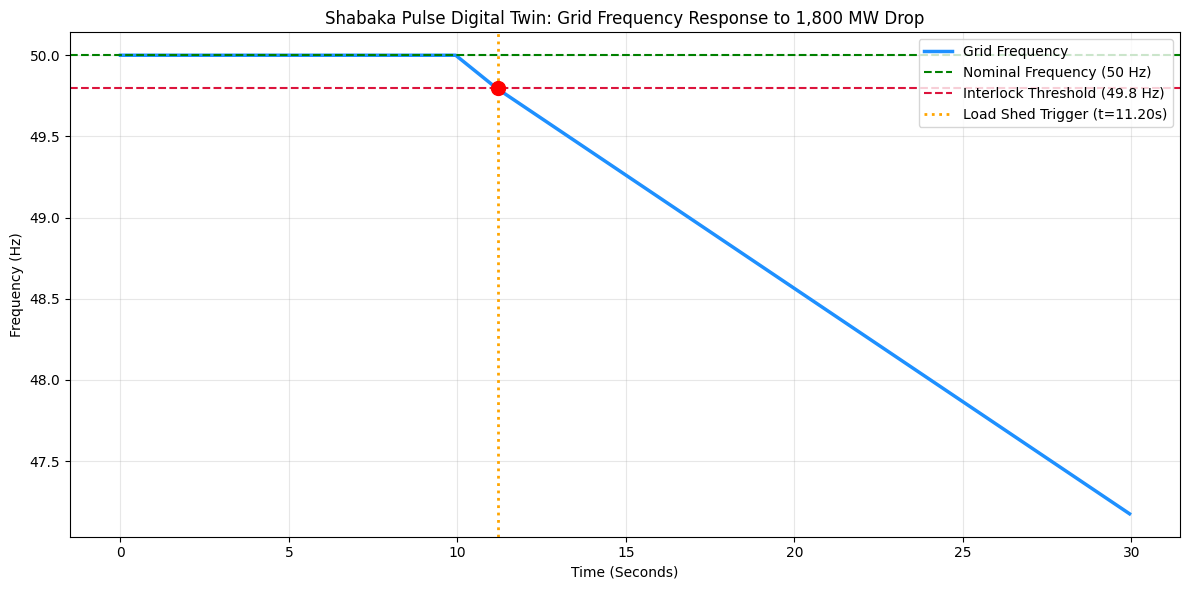

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(sim_df["Time (s)"], sim_df["Frequency (Hz)"], color="dodgerblue", linewidth=2.5, label="Grid Frequency")

ax.axhline(F_NOMINAL_HZ, color="green", linestyle="--", linewidth=1.5, label="Nominal Frequency (50 Hz)")
ax.axhline(INTERLOCK_THRESHOLD_HZ, color="crimson", linestyle="--", linewidth=1.5, label="Interlock Threshold (49.8 Hz)")

if trigger_time is not None:
    ax.axvline(trigger_time, color="orange", linestyle=":", linewidth=2, label=f"Load Shed Trigger (t={trigger_time:.2f}s)")
    ax.scatter([trigger_time], [INTERLOCK_THRESHOLD_HZ], color="red", s=100, zorder=5)

ax.set_title("Shabaka Pulse Digital Twin: Grid Frequency Response to 1,800 MW Drop")
ax.set_xlabel("Time (Seconds)")
ax.set_ylabel("Frequency (Hz)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()